In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/ChronicKidneyDisease.csv'
df2 = pd.read_csv(file_path)
df2

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,80.0,1.020,0.0,0.0,1.0,49.0,0.5,150.00,4.90,15.7,6700.0,4.90,0.0,0
396,70.0,1.025,0.0,0.0,1.0,31.0,1.2,141.00,3.50,16.5,7800.0,6.20,0.0,0
397,80.0,1.020,0.0,0.0,1.0,26.0,0.6,137.00,4.40,15.8,6600.0,5.40,0.0,0
398,60.0,1.025,0.0,0.0,1.0,50.0,1.0,135.00,4.90,14.2,7200.0,5.90,0.0,0


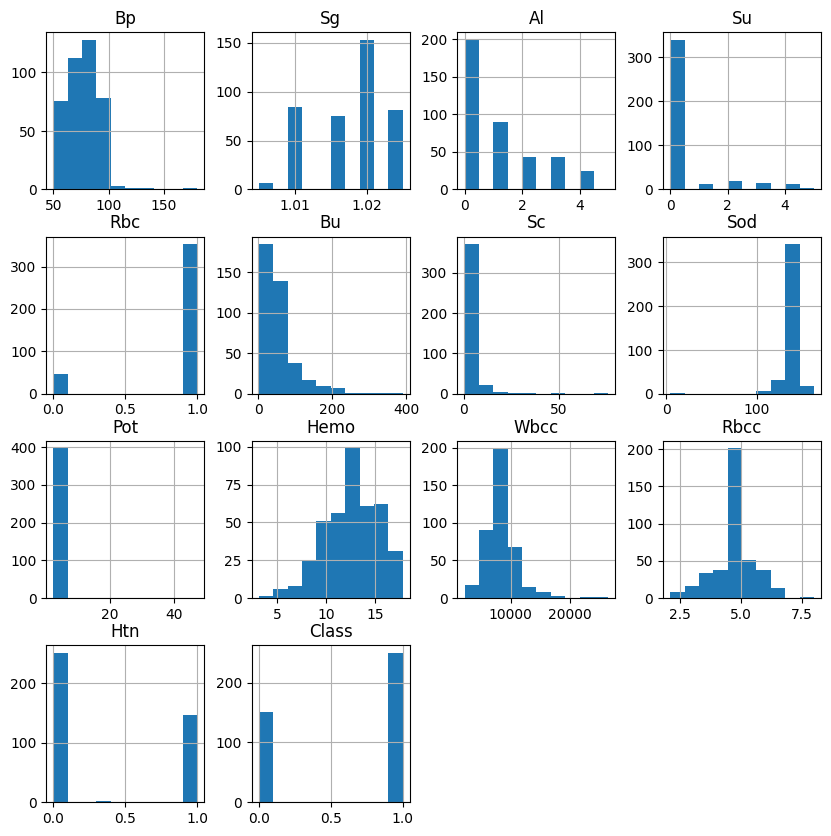

In [ ]:
df2.hist(figsize=(10, 10))
plt.show()

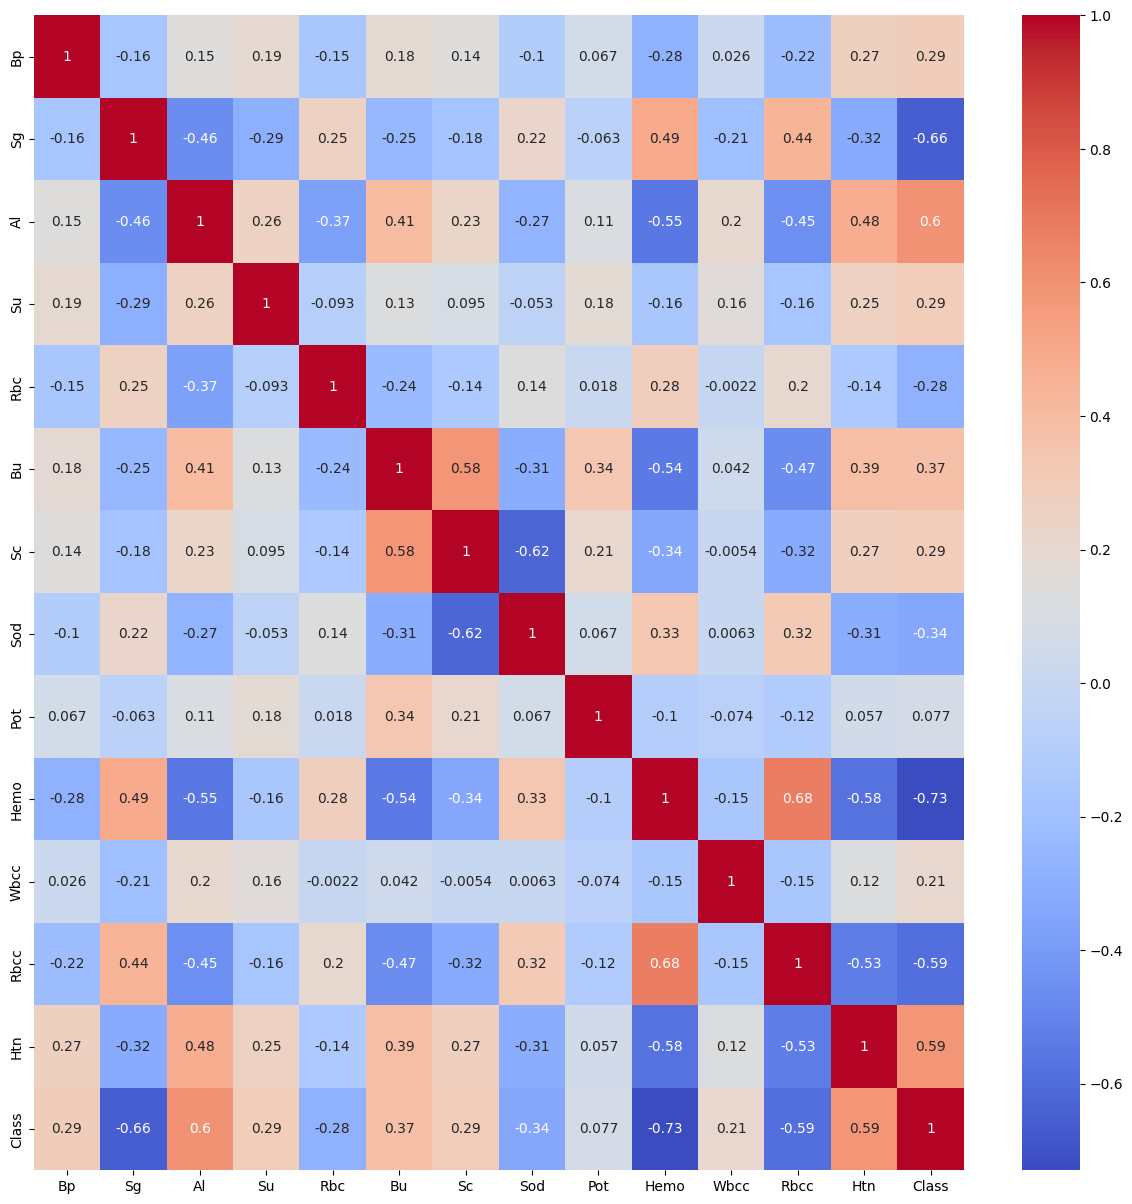

In [ ]:
plt.figure(figsize=(15,15))
corr_matrix = df2.corr()
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm')
plt.show()

In [ ]:
x = df2.drop('Class',axis=1)
y = df2['Class']

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Logistic Regression Accuracy: ")
accuracy_score(y_test, y_pred)

Logistic Regression Accuracy: 


0.975

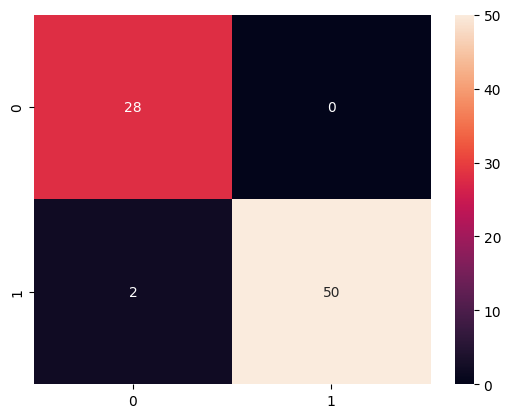

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
input_values = []
for col in x.columns:
  val = float(input(f"Enter {col}: "))
  input_values.append(val)

features_to_predict = np.array(input_values).reshape(1,-1)
features_scaled = scaler.transform(features_to_predict)

prediction = lr.predict(features_scaled)
if(prediction[0] ==1):
  print("1")
else:
  print("0")

Enter Bp: 80
Enter Sg: 1.02
Enter Al: 1
Enter Su: 0
Enter Rbc: 1
Enter Bu: 36
Enter Sc: 1.2
Enter Sod: 137.53
Enter Pot: 4.63
Enter Hemo: 15.4
Enter Wbcc: 7800
Enter Rbcc: 5.2
Enter Htn: 1
0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
